In [1]:
from pathlib import Path
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [2]:
cv_data_root_path = Path("/Users/irabandutta/Developer/2026-06-deep-learning-workbench/00_foundations/computer_vision/data")
cifar10_path = cv_data_root_path / "cifar10"

In [3]:

if cifar10_path.is_dir():
    print(f"Loading CIFAR10 data from {cifar10_path}")
    for item in cifar10_path.iterdir():
        print(item)



Loading CIFAR10 data from /Users/irabandutta/Developer/2026-06-deep-learning-workbench/00_foundations/computer_vision/data/cifar10
/Users/irabandutta/Developer/2026-06-deep-learning-workbench/00_foundations/computer_vision/data/cifar10/data_batch_1
/Users/irabandutta/Developer/2026-06-deep-learning-workbench/00_foundations/computer_vision/data/cifar10/readme.html
/Users/irabandutta/Developer/2026-06-deep-learning-workbench/00_foundations/computer_vision/data/cifar10/batches.meta
/Users/irabandutta/Developer/2026-06-deep-learning-workbench/00_foundations/computer_vision/data/cifar10/data_batch_2
/Users/irabandutta/Developer/2026-06-deep-learning-workbench/00_foundations/computer_vision/data/cifar10/data_batch_5
/Users/irabandutta/Developer/2026-06-deep-learning-workbench/00_foundations/computer_vision/data/cifar10/test_batch
/Users/irabandutta/Developer/2026-06-deep-learning-workbench/00_foundations/computer_vision/data/cifar10/data_batch_4
/Users/irabandutta/Developer/2026-06-deep-lear

In [4]:
# Get file names with data_batch_i
for i in range(1, 6):
    file_path = cifar10_path / f'data_batch_{i}'
    print(file_path)

/Users/irabandutta/Developer/2026-06-deep-learning-workbench/00_foundations/computer_vision/data/cifar10/data_batch_1
/Users/irabandutta/Developer/2026-06-deep-learning-workbench/00_foundations/computer_vision/data/cifar10/data_batch_2
/Users/irabandutta/Developer/2026-06-deep-learning-workbench/00_foundations/computer_vision/data/cifar10/data_batch_3
/Users/irabandutta/Developer/2026-06-deep-learning-workbench/00_foundations/computer_vision/data/cifar10/data_batch_4
/Users/irabandutta/Developer/2026-06-deep-learning-workbench/00_foundations/computer_vision/data/cifar10/data_batch_5


In [5]:
# Explore one specific data_batch_i
with open(file_path, 'rb') as f:
    data = pickle.load(f, encoding='bytes')
    data = {k.decode('utf=8'):v for k, v in data.items()}

data

{'batch_label': b'training batch 5 of 5',
 'labels': [1,
  8,
  5,
  1,
  5,
  7,
  4,
  3,
  8,
  2,
  7,
  2,
  0,
  1,
  5,
  9,
  6,
  2,
  0,
  8,
  2,
  7,
  0,
  4,
  1,
  7,
  7,
  4,
  4,
  9,
  9,
  6,
  2,
  4,
  1,
  6,
  4,
  9,
  6,
  6,
  9,
  6,
  9,
  9,
  5,
  7,
  1,
  6,
  8,
  2,
  9,
  5,
  9,
  5,
  3,
  7,
  1,
  3,
  3,
  9,
  1,
  7,
  8,
  9,
  7,
  4,
  3,
  4,
  9,
  5,
  8,
  4,
  9,
  3,
  6,
  1,
  1,
  4,
  3,
  9,
  9,
  1,
  9,
  9,
  2,
  4,
  3,
  2,
  4,
  7,
  1,
  5,
  1,
  8,
  6,
  3,
  6,
  3,
  4,
  4,
  9,
  9,
  9,
  7,
  0,
  5,
  7,
  7,
  4,
  8,
  8,
  4,
  2,
  0,
  5,
  2,
  4,
  9,
  1,
  7,
  7,
  4,
  8,
  8,
  8,
  0,
  2,
  3,
  6,
  3,
  9,
  0,
  8,
  2,
  2,
  4,
  8,
  8,
  1,
  8,
  5,
  7,
  6,
  0,
  9,
  1,
  4,
  8,
  2,
  1,
  0,
  5,
  1,
  6,
  5,
  3,
  4,
  9,
  9,
  0,
  3,
  5,
  4,
  2,
  6,
  3,
  9,
  4,
  9,
  8,
  6,
  4,
  1,
  1,
  9,
  8,
  2,
  2,
  1,
  8,
  5,
  9,
  7,
  8,
  1,
  1,
  4,
  2,
  4,
  2

In [6]:
data.keys()

dict_keys(['batch_label', 'labels', 'data', 'filenames'])

In [7]:
for k in data.keys():
    print(f"Key: {k}, Value_Type: {type(data[k])}")

Key: batch_label, Value_Type: <class 'bytes'>
Key: labels, Value_Type: <class 'list'>
Key: data, Value_Type: <class 'numpy.ndarray'>
Key: filenames, Value_Type: <class 'list'>


In [8]:
# Number of samples in batch
len(data['labels'])

10000

In [9]:
# Shape of data in batch
data['data'].shape

(10000, 3072)

In [10]:
# Inspect a sample image:
sample_img = data['data'][0:1]
print(sample_img.shape)

print(sample_img[:, 0:10])
print(sample_img[:, 1024:1034])
print(sample_img[:, 2048:2058])

(1, 3072)
[[255 252 253 250 238 233 245 241 232 238]]
[[255 252 252 252 243 237 249 246 238 244]]
[[254 252 254 254 247 242 252 249 241 247]]


In [11]:
# Creating 3 changes
sample_img = sample_img.reshape(1, 3, -1)
print(sample_img.shape)

print(sample_img[:, 0, 0:10])
print(sample_img[:, 1, 0:10])
print(sample_img[:, 2, 0:10])

(1, 3, 1024)
[[255 252 253 250 238 233 245 241 232 238]]
[[255 252 252 252 243 237 249 246 238 244]]
[[254 252 254 254 247 242 252 249 241 247]]


In [12]:
# Creating tensor of shape: (B, r, c, chn)
sample_img = sample_img.reshape(1, 3, 32, 32)
sample_img.shape

(1, 3, 32, 32)

In [13]:
sample_img_transposed = np.transpose(sample_img[0], axes=(1, 2, 0))
sample_img_transposed.shape

(32, 32, 3)

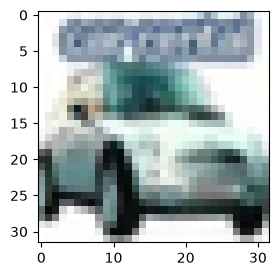

In [14]:
plt.figure(figsize=(3, 3))
plt.imshow(sample_img_transposed)
plt.show()

# **Final Function**

## **Notes: NumPy Tensor Shape Concat/Stack Cheat Sheet**

We'll use the following two matrices throughout:

```python
A = np.array([
    [1, 2],
    [3, 4]
])

B = np.array([
    [5, 6],
    [7, 8]
])
```

Both have shape:

```text
(2, 2)
```

---

### **Core Mental Model**

Before choosing an operation, ask yourself:

> **Am I making an existing dimension larger, or am I creating a new dimension?**

| Function | Existing axis grows? | New axis created? |
|:---------|:---------------------|:------------------|
| `concatenate()` | ✅ Yes | ❌ No |
| `stack()` | ❌ No | ✅ Yes |
| `reshape()` | ❌ No | ❌ No |
| `expand_dims()` | ❌ No | ✅ Yes (size = 1) |
| `squeeze()` | ❌ No | Removes size-1 axis |

---

### **1. `np.concatenate()`**

Joins tensors **along an existing axis**.

#### **Example 1 — Concatenate along Rows (`axis=0`)**

```python
np.concatenate([A, B], axis=0)
```

```text
A              B

1 2            5 6
3 4            7 8

↓

1 2
3 4
5 6
7 8
```

Shape:

```text
(2,2)
+
(2,2)

↓

(4,2)
```

> **Memory:** `axis=0` → existing row dimension becomes larger.

---

#### **Example 2 — Concatenate along Columns (`axis=1`)**

```python
np.concatenate([A, B], axis=1)
```

```text
A      B

1 2 | 5 6
3 4 | 7 8
```

Result

```text
1 2 5 6
3 4 7 8
```

Shape

```text
(2,2)
+
(2,2)

↓

(2,4)
```

> **Memory:** `axis=1` → existing column dimension becomes larger.

---

#### **2. `np.stack()`**

Unlike `concatenate()`, **stack inserts an entirely new dimension**.

Think of it as:

```text
Existing arrays

↓

Insert a new axis

↓

Place arrays along that axis
```

---

#### **Example 1 — Stack along `axis=0`**

```python
np.stack([A, B], axis=0)
```

Visualize:

```text
Layer 0

1 2
3 4

────────────

Layer 1

5 6
7 8
```

Shape

```text
(2,2)

↓

(2,2,2)

Meaning

2 matrices
│
├── each has 2 rows
│
└── each row has 2 columns
```

Notice:

The new axis becomes the **outermost** dimension.

---

#### **Example 2 — Stack along `axis=1`**

```python
np.stack([A, B], axis=1)
```

Instead of stacking complete matrices,

we insert a new dimension **between rows and columns**.

Think row-by-row:

```text
Original

A             B

1 2           5 6
3 4           7 8
```

After stacking:

```text
Row 0

[
   [1 2],      ← from A
   [5 6]       ← from B
]

Row 1

[
   [3 4],
   [7 8]
]
```

Shape

```text
(2,2)

↓

(2,2,2)

Meaning

2 rows
│
├── each row contains 2 arrays
│
└── each array has 2 elements
```

Notice:

The shape is still `(2,2,2)`, but **the meaning of each axis has changed**.

---

#### **Example 3 — Stack along `axis=-1` (Innermost Dimension)**

```python
np.stack([A, B], axis=-1)
```

Now every element becomes a pair.

```text
Original

A        B

1        5

↓

[1,5]
```

Entire result

```text
[
 [[1,5], [2,6]],

 [[3,7], [4,8]]
]
```

Shape

```text
(2,2)

↓

(2,2,2)

Meaning

2 rows

↓

2 columns

↓

2 values stored at every position
```

Visualize one element:

```text
Before

1


After

[1,5]
```

> **Memory:** `axis=-1` creates a new **innermost** dimension.

---

### **Concatenate vs Stack**

These two are often confused.

#### **Concatenate**

```python
np.concatenate([A,B], axis=0)
```

```text
1 2
3 4
5 6
7 8
```

Shape

```text
(4,2)
```

Existing dimension became larger.

---

#### **Stack**

```python
np.stack([A,B], axis=0)
```

```text
Layer 0

1 2
3 4

Layer 1

5 6
7 8
```

Shape

```text
(2,2,2)
```

A completely **new dimension** was created.

---

### **3. `np.reshape()`**

Changes the **shape**, **not the data**.

```python
x = np.arange(12)
```

Shape

```text
(12,)
```

---

#### Example 1

```python
x.reshape(3,4)
```

```text
0  1  2  3
4  5  6  7
8  9 10 11
```

Shape

```text
(3,4)
```

---

#### Example 2

```python
x.reshape(2,2,3)
```

Shape

```text
(2,2,3)
```

The elements stay in the same order.

> **Memory:** Total number of elements must remain unchanged.

---

### **4. `np.expand_dims()`**

Adds a dimension of size **1**.

Suppose

```python
x.shape
```

```text
(3,4)
```

---

#### Add a leading dimension

```python
np.expand_dims(x, axis=0)
```

Shape

```text
(1,3,4)
```

Think

```text
1 matrix

↓

3 rows

↓

4 columns
```

---

#### Add a trailing dimension

```python
np.expand_dims(x, axis=-1)
```

Shape

```text
(3,4,1)
```

Useful for images:

```text
(H,W)

↓

(H,W,1)
```

---

### **5. `np.squeeze()`**

Removes every dimension whose size is **1**.

Suppose

```python
x.shape
```

```text
(1,3,4,1)
```

Then

```python
np.squeeze(x)
```

Shape

```text
(3,4)
```

Only dimensions with size **1** are removed.

---

### **expand_dims() ↔ squeeze()**

These are inverse operations.

```text
(3,4)

↓

expand_dims(axis=0)

↓

(1,3,4)

↓

squeeze()

↓

(3,4)
```

---

### **Quick Reference**

| Function | Input | Output | Purpose |
|:---------|:------|:-------|:--------|
| `concatenate(axis=0)` | `(2,2)+(2,2)` | `(4,2)` | Join rows |
| `concatenate(axis=1)` | `(2,2)+(2,2)` | `(2,4)` | Join columns |
| `stack(axis=0)` | `(2,2)+(2,2)` | `(2,2,2)` | New outer dimension |
| `stack(axis=1)` | `(2,2)+(2,2)` | `(2,2,2)` | New middle dimension |
| `stack(axis=-1)` | `(2,2)+(2,2)` | `(2,2,2)` | New inner dimension |
| `reshape(3,4)` | `(12,)` | `(3,4)` | Rearrange shape |
| `expand_dims(axis=0)` | `(3,4)` | `(1,3,4)` | Add leading dimension |
| `expand_dims(axis=-1)` | `(3,4)` | `(3,4,1)` | Add trailing dimension |
| `squeeze()` | `(1,3,4,1)` | `(3,4)` | Remove size-1 dimensions |

---

### **Final Memory Rules**

1. **`concatenate()`** → make an **existing dimension larger**.
2. **`stack()`** → create a **new dimension**.
3. **`reshape()`** → change shape, not data.
4. **`expand_dims()`** → add a size-1 dimension.
5. **`squeeze()`** → remove size-1 dimensions.
6. **`stack()` does NOT combine arrays side-by-side—it inserts a new axis first, then places the arrays along that axis.**
7. **`concatenate()` changes shape by growing an existing axis; `stack()` changes rank by adding a new axis.**

In [15]:
def load_cifar10_batch(file_path):

    if file_path.is_file():
        import pickle
        with open(file_path, "rb") as f:
            batch = pickle.load(f, encoding='bytes')
            batch = {k.decode('utf-8'):v for k, v in batch.items()}
        
        B = batch["data"].shape[0]
        X = batch["data"].reshape(B, 3, 32, 32)
        Y = batch["labels"]
        return X, Y
    
    return None, None


def load_cifar10(folder_path):
    if folder_path.is_dir():

        xtr, ytr = [], []
        # Iterate over train_data_batches
        for i in range(1, 6):
            file_path = folder_path / f"data_batch_{i}"
            X_batch, Y_batch = load_cifar10_batch(file_path)
            xtr.append(X_batch)
            ytr = ytr + Y_batch

        # Train batches: Concatenate
        Xtr = np.concatenate(xtr, axis=0)
        Ytr = np.array(ytr)

        # Iterate over train_data_batches
        file_path = folder_path / f"test_batch"
        Xts, Yts = load_cifar10_batch(file_path)
        Yts = np.array(Yts)

        # Get label idx to name mapping
        mapping_file_path = folder_path / "batches.meta"
        import pickle
        with open(mapping_file_path, "rb") as f:
            label_map = pickle.load(f, encoding='bytes')
            label_map = {k.decode('utf-8'):v for k, v in label_map.items()}
            label_map["label_names"] = [name.decode('utf-8') for name in label_map["label_names"]]
        
        
        return Xtr, Ytr, Xts, Yts, label_map
    
    return None, None, None, None, None

X_train, Y_train, X_test, Y_test, label_map = load_cifar10(cifar10_path)


print(X_train.shape, Y_train.shape)
print(X_test.shape, Y_test.shape)

(50000, 3, 32, 32) (50000,)
(10000, 3, 32, 32) (10000,)


In [16]:
label_map

{'num_cases_per_batch': 10000,
 'label_names': ['airplane',
  'automobile',
  'bird',
  'cat',
  'deer',
  'dog',
  'frog',
  'horse',
  'ship',
  'truck'],
 'num_vis': 3072}

In [17]:
label_map['label_names'][0]

'airplane'